Reading: /public/home/caozhinan/BioMPNN/wandb/offline-run-20260412_161820-de1vsias
  Read 646518 history records


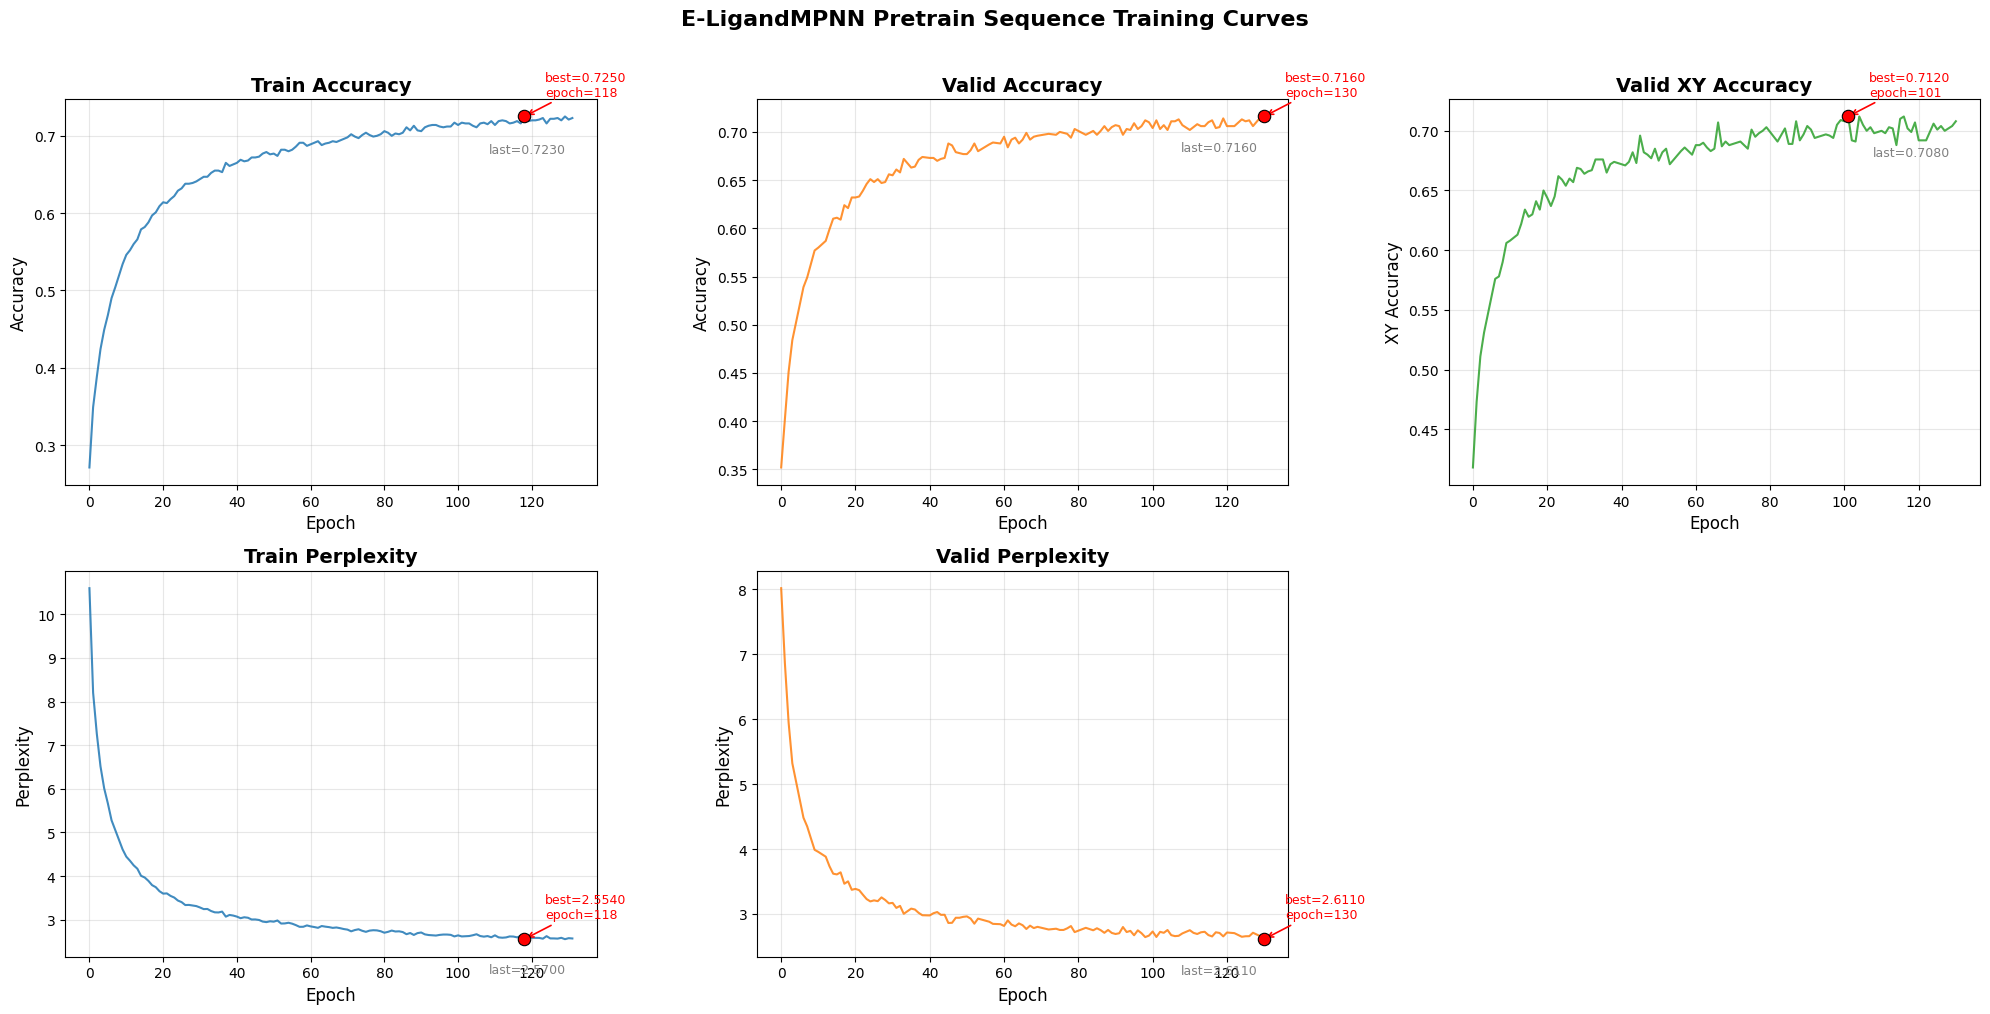


  Training Summary
  train/epoch_accuracy                      best=0.7250 @ epoch 118,  last=0.7230
  valid/epoch_accuracy                      best=0.7160 @ epoch 130,  last=0.7160
  valid/epoch_XY_accuracy                   best=0.7120 @ epoch 101,  last=0.7080
  train/epoch_perplexity                    best=2.5540 @ epoch 118,  last=2.5700
  valid/epoch_perplexity                    best=2.6110 @ epoch 130,  last=2.6110

  Epoch 100 Metrics
  train/epoch_accuracy                      0.7140
  valid/epoch_accuracy                      0.7040
  valid/epoch_XY_accuracy                   0.7080
  train/epoch_perplexity                    2.6410
  valid/epoch_perplexity                    2.7290


In [1]:
# ============================================================  
# 一键运行: 从 wandb 离线数据绘制训练曲线  
# ============================================================  
import os, glob, json  
import numpy as np  
import matplotlib.pyplot as plt  
from collections import defaultdict  
  
WANDB_DIR = "/public/home/caozhinan/BioMPNN/wandb"  
  
# ===== 指定要查看的 epoch =====  
QUERY_EPOCHS = [100]  # 改成你想查的 epoch，比如 [50, 100, 150, 200]  
  
# ---------- 读取 wandb 离线数据 ----------  
def read_wandb_offline(wandb_dir):  
    run_dirs = sorted(glob.glob(os.path.join(wandb_dir, "offline-run-*")))  
    if not run_dirs:  
        run_dirs = sorted(glob.glob(os.path.join(wandb_dir, "run-*")))  
    assert run_dirs, f"No wandb run dirs found in {wandb_dir}"  
    run_dir = run_dirs[-1]  
    print(f"Reading: {run_dir}")  
  
    wandb_files = sorted(glob.glob(os.path.join(run_dir, "*.wandb")))  
    assert wandb_files, f"No .wandb files in {run_dir}"  
  
    from wandb.sdk.internal.datastore import DataStore  
    from wandb.proto import wandb_internal_pb2  
  
    ds = DataStore()  
    ds.open_for_scan(wandb_files[-1])  
    records = []  
    while True:  
        data = ds.scan_data()  
        if data is None:  
            break  
        try:  
            rec = wandb_internal_pb2.Record()  
            rec.ParseFromString(data)  
            if rec.HasField('history'):  
                item = {}  
                for kv in rec.history.item:  
                    try:  
                        item[kv.key] = json.loads(kv.value_json)  
                    except (json.JSONDecodeError, ValueError):  
                        pass  
                if item:  
                    records.append(item)  
        except Exception:  
            continue  
    ds.close()  
    print(f"  Read {len(records)} history records")  
    return records  
  
# ---------- 提取 epoch 级别指标 ----------  
def extract_epoch_metrics(records):  
    epoch_keys = [  
        'train/epoch_perplexity', 'train/epoch_accuracy',  
        'valid/epoch_perplexity', 'valid/epoch_accuracy',  
        'valid/epoch_XY_accuracy',  
    ]  
    metrics = defaultdict(list)  
    for rec in records:  
        if not any(k in rec for k in epoch_keys):  
            continue  
        epoch = rec.get('epoch', None)  
        if epoch is None:  
            continue  
        for key in epoch_keys:  
            if key in rec and rec[key] is not None:  
                metrics[key].append((epoch, rec[key]))  
    return metrics  
  
# ---------- 打印指定 epoch 的各项指标 ----------  
def print_epoch_metrics(metrics, target_epochs, plot_configs):  
    """打印指定 epoch 的各项指标。target_epochs 可以是单个数字或列表。"""  
    if isinstance(target_epochs, (int, float)):  
        target_epochs = [target_epochs]  
    target_epochs = sorted(target_epochs)  
  
    # 为每个 key 建立 epoch -> value 的映射  
    epoch_map = {}  
    for key, _, _, _, _, _ in plot_configs:  
        if key not in metrics or not metrics[key]:  
            continue  
        epoch_map[key] = {epoch: val for epoch, val in metrics[key]}  
  
    for ep in target_epochs:  
        print(f"\n{'=' * 65}")  
        print(f"  Epoch {ep} Metrics")  
        print(f"{'=' * 65}")  
        found_any = False  
        for key, _, _, _, _, _ in plot_configs:  
            if key not in epoch_map:  
                print(f"  {key:40s}  (no data)")  
                continue  
            if ep in epoch_map[key]:  
                print(f"  {key:40s}  {epoch_map[key][ep]:.4f}")  
                found_any = True  
            else:  
                # 找最近的 epoch  
                available = sorted(epoch_map[key].keys())  
                closest = min(available, key=lambda x: abs(x - ep))  
                print(f"  {key:40s}  (no exact match, closest epoch {closest} = {epoch_map[key][closest]:.4f})")  
        if not found_any:  
            print(f"  No data found for epoch {ep}")  
        print(f"{'=' * 65}")  
  
# ---------- 读取数据 ----------  
records = read_wandb_offline(WANDB_DIR)  
metrics = extract_epoch_metrics(records)  
  
# ---------- 绘图 ----------  
fig, axes = plt.subplots(2, 3, figsize=(20, 10))  
  
plot_configs = [  
    ('train/epoch_accuracy',     'Train Accuracy',     axes[0, 0], '#1f77b4', 'Accuracy',   'max'),  
    ('valid/epoch_accuracy',     'Valid Accuracy',      axes[0, 1], '#ff7f0e', 'Accuracy',   'max'),  
    ('valid/epoch_XY_accuracy',  'Valid XY Accuracy',   axes[0, 2], '#2ca02c', 'XY Accuracy','max'),  
    ('train/epoch_perplexity',   'Train Perplexity',    axes[1, 0], '#1f77b4', 'Perplexity', 'min'),  
    ('valid/epoch_perplexity',   'Valid Perplexity',    axes[1, 1], '#ff7f0e', 'Perplexity', 'min'),  
]  
  
# 隐藏最后一个空子图  
axes[1, 2].axis('off')  
  
for key, title, ax, color, ylabel, best_mode in plot_configs:  
    if key not in metrics or not metrics[key]:  
        ax.set_title(f"{title}\n(no data)", fontsize=13)  
        continue  
  
    data = sorted(metrics[key], key=lambda x: x[0])  
    epochs = [d[0] for d in data]  
    values = [d[1] for d in data]  
  
    ax.plot(epochs, values, color=color, linewidth=1.5, alpha=0.85)  
  
    # 标注最佳点  
    if best_mode == 'max':  
        best_idx = int(np.argmax(values))  
    else:  
        best_idx = int(np.argmin(values))  
    best_epoch, best_val = epochs[best_idx], values[best_idx]  
  
    ax.scatter([best_epoch], [best_val], color='red', s=80, zorder=5, edgecolors='black', linewidths=0.8)  
    ax.annotate(f'best={best_val:.4f}\nepoch={best_epoch}',  
                xy=(best_epoch, best_val),  
                xytext=(15, 15), textcoords='offset points',  
                fontsize=9, color='red',  
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))  
  
    # 标注最后一个点  
    last_epoch, last_val = epochs[-1], values[-1]  
    ax.annotate(f'last={last_val:.4f}', xy=(last_epoch, last_val),  
                xytext=(-60, -25), textcoords='offset points',  
                fontsize=9, color='gray')  
  
    ax.set_title(title, fontsize=14, fontweight='bold')  
    ax.set_xlabel('Epoch', fontsize=12)  
    ax.set_ylabel(ylabel, fontsize=12)  
    ax.grid(True, alpha=0.3)  
  
plt.suptitle('E-LigandMPNN Pretrain Sequence Training Curves', fontsize=16, fontweight='bold', y=1.01)  
plt.tight_layout()  
plt.show()  
  
# ---------- 打印摘要 ----------  
print("\n" + "=" * 65)  
print("  Training Summary")  
print("=" * 65)  
for key, _, _, _, _, best_mode in plot_configs:  
    if key not in metrics or not metrics[key]:  
        continue  
    data = sorted(metrics[key], key=lambda x: x[0])  
    values = [d[1] for d in data]  
    epochs = [d[0] for d in data]  
    best_idx = int(np.argmax(values)) if best_mode == 'max' else int(np.argmin(values))  
    print(f"  {key:40s}  best={values[best_idx]:.4f} @ epoch {epochs[best_idx]},  last={values[-1]:.4f}")  
print("=" * 65)  
  
# ---------- 打印指定 epoch 的指标 ----------  
print_epoch_metrics(metrics, QUERY_EPOCHS, plot_configs)